In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping      ## importing

In [24]:
df = pd.read_csv("train.csv") ## read the data

In [25]:
df.head() ## checking data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [26]:
X = df.drop('price_range', axis=1)
y = df['price_range'].values      ## configuring features, and output

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) ## configuring test,train data

In [28]:
data_pipeline = Pipeline([ 
    ('scaler', StandardScaler())      ## for battery mhz numbers or other numbers
   
])

X_train_ready = data_pipeline.fit_transform(X_train)
X_test_ready = data_pipeline.transform(X_test)       ## fit and transform

In [29]:
## setting the model
model = Sequential([
    # input layer
    Input(shape=(X_train_ready.shape[1],)), 
    
    # hidden layers
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    
    # output there are 4 layers
    Dense(4, activation='softmax') 
])

In [30]:
##tuning the model
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [31]:
## earylystop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [32]:
# fitting the model
history = model.fit(
    X_train_ready, y_train,        
    epochs=100,                    
    batch_size=32,                 
    validation_split=0.2,          
    callbacks=[early_stop],        
    verbose=1                      
)

Epoch 1/100
40/40 [==============================] - 0s 1ms/step - loss: 1.3307 - accuracy: 0.3734 - val_loss: 1.2229 - val_accuracy: 0.4594
Epoch 2/100
40/40 [==============================] - 0s 571us/step - loss: 1.0898 - accuracy: 0.5625 - val_loss: 0.9975 - val_accuracy: 0.5656
Epoch 3/100
40/40 [==============================] - 0s 521us/step - loss: 0.8460 - accuracy: 0.6812 - val_loss: 0.7908 - val_accuracy: 0.6594
Epoch 4/100
40/40 [==============================] - 0s 571us/step - loss: 0.6680 - accuracy: 0.7773 - val_loss: 0.6445 - val_accuracy: 0.7500
Epoch 5/100
40/40 [==============================] - 0s 529us/step - loss: 0.5391 - accuracy: 0.8344 - val_loss: 0.5379 - val_accuracy: 0.8031
Epoch 6/100
40/40 [==============================] - 0s 507us/step - loss: 0.4440 - accuracy: 0.8609 - val_loss: 0.4591 - val_accuracy: 0.8531
Epoch 7/100
40/40 [==============================] - 0s 509us/step - loss: 0.3708 - accuracy: 0.9031 - val_loss: 0.3991 - val_accuracy: 0.8531
E

In [33]:
print("\nModel Checking the data")
loss, accuracy = model.evaluate(X_test_ready, y_test, verbose=0) 
print("-" * 40)
print(f"Accuracy: {accuracy:.2%}")
print("-" * 40)


Model Checking the data
----------------------------------------
Accuracy: 93.25%
----------------------------------------


In [34]:
y_pred_probs = model.predict(X_test_ready)

13/13 [==============================] - 0s 325us/step


In [35]:
y_pred = np.argmax(y_pred_probs, axis=1) ## configure for matrix

In [36]:
print(classification_report(y_test, y_pred, target_names=['Cheap (0)', 'Medium (1)', 'Expensive (2)', 'Very Expensive (3)']))

                    precision    recall  f1-score   support

         Cheap (0)       0.97      0.97      0.97       105
        Medium (1)       0.90      0.92      0.91        91
     Expensive (2)       0.91      0.86      0.88        92
Very Expensive (3)       0.94      0.96      0.95       112

          accuracy                           0.93       400
         macro avg       0.93      0.93      0.93       400
      weighted avg       0.93      0.93      0.93       400



In [37]:
cm = confusion_matrix(y_test, y_pred)

<Axes: >

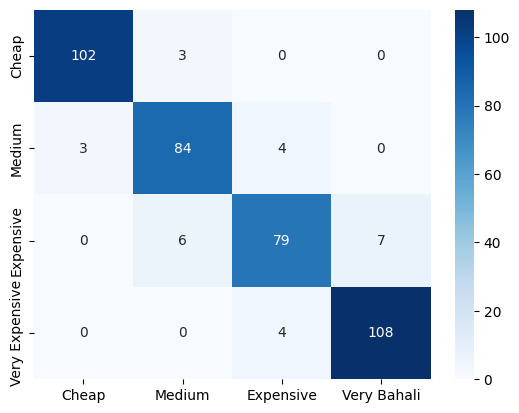

In [38]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cheap', 'Medium', 'Expensive', 'Very Bahali'], 
            yticklabels=['Cheap', 'Medium', 'Expensive', 'Very Expensive'])